## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
tf.set_random_seed(42)
import numpy as np
from keras.utils import to_categorical

Using TensorFlow backend.


In [2]:
from keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

4423680/4422102 [==============================] - 2s 1us/step


### Find no.of samples are there in training and test datasets

In [3]:
print("x_train shape:",X_train.shape, "y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28) y_train shape: (60000,)


In [4]:
print("x_test shape:", X_test.shape, "y_test shape:", y_test.shape)

x_test shape: (10000, 28, 28) y_test shape: (10000,)


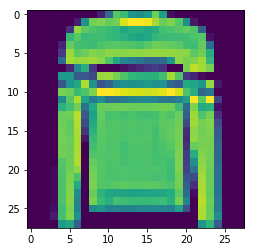

In [5]:
# Show one of the images from the training dataset
img_index=5
plt.imshow(X_train[img_index])

### Find dimensions of an image in the dataset

In [6]:
X_train[1].shape

(28, 28)

convert each 28 x 28 image of the train and test set into a matrix of size 28 x 28 x 1 which is fed into the network.

In [7]:
X_train = X_train.reshape(-1, 28,28, 1)
X_test = X_test.reshape(-1, 28,28, 1)
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

The data right now is in an int8 format, so before you feed it into the network you need to convert its type to float32

In [0]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [9]:
# Change the labels from categorical to one-hot encoding
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)
#Display the change for category label using one-hot encoding
print('Original label:', y_train[0])
print('After conversion to one-hot:', y_train_one_hot[0])

Original label: 9
After conversion to one-hot: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [10]:
print(y_train.shape)
print('First 5 examples now are: ', y_train[0:5])

(60000,)
First 5 examples now are:  [9 0 0 3 0]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

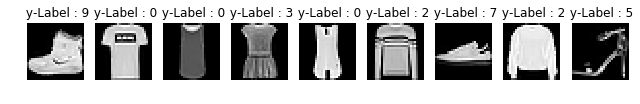

In [11]:
plt.figure(figsize = (12,2))
for i in range(1,10):
    plt.subplot(1,10,i)    
    plt.imshow(X_train[i-1].reshape(28,28), cmap='gray', interpolation='nearest')
    plt.axis('off')
    plt.title(" y-Label : {}".format(y_train[i-1]))
    # plt.tight_layout()

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
X_train = X_train / 255.

In [0]:
X_test = X_test / 255.

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
---Done Already-------

### Import the necessary layers from keras to build the model

In [0]:
import keras
from keras.models import Sequential,Input,Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers.advanced_activations import LeakyReLU
from keras.optimizers import SGD
from sklearn.model_selection import train_test_split

In [0]:
# Split the data set into training and testing
X_traini, X_testi, y_traini, y_testi = train_test_split(X_train, y_train_one_hot, test_size=0.2, random_state=7)

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [0]:
#Initialize model, reshape & normalize data
model = tf.keras.models.Sequential()

#Add Layers
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
checkpt= tf.keras.callbacks.EarlyStopping(monitor='acc',  patience=5, verbose=0, mode='auto', baseline=None, restore_best_weights=True)

In [36]:
# Fit the model
model.fit(X_traini, y_traini, epochs=10, batch_size=5,callbacks = [checkpt])

Epoch 1/10
48000/48000 [==============================] - 35s 724us/sample - loss: 0.3761 - acc: 0.8638
Epoch 2/10
48000/48000 [==============================] - 34s 718us/sample - loss: 0.2334 - acc: 0.9129
Epoch 3/10
48000/48000 [==============================] - 35s 719us/sample - loss: 0.1614 - acc: 0.9396
Epoch 4/10
48000/48000 [==============================] - 34s 714us/sample - loss: 0.1115 - acc: 0.9591
Epoch 5/10
48000/48000 [==============================] - 34s 716us/sample - loss: 0.0763 - acc: 0.9727
Epoch 6/10
48000/48000 [==============================] - 34s 716us/sample - loss: 0.0532 - acc: 0.9809
Epoch 7/10
48000/48000 [==============================] - 35s 727us/sample - loss: 0.0418 - acc: 0.9852
Epoch 8/10
48000/48000 [==============================] - 34s 713us/sample - loss: 0.0354 - acc: 0.9880
Epoch 9/10
48000/48000 [==============================] - 34s 718us/sample - loss: 0.0282 - acc: 0.9909
Epoch 10/10
48000/48000 [==============================] - 34s 7

In [0]:
test_eval = model.evaluate(X_test, y_test_one_hot, verbose=0)

In [38]:
print('Test loss: ', test_eval[0])
print('Test accuracy:  % 5.2f' % (test_eval[1]*100) ,'%' )

Test loss:  0.9509363410141551
Test accuracy:   90.43 %


### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
#Initialize model, reshape & normalize data
model_a = tf.keras.models.Sequential()

#Add Layers
model_a.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model_a.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model_a.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model_a.add(tf.keras.layers.Dropout(0.25))
model_a.add(tf.keras.layers.Flatten())
model_a.add(tf.keras.layers.Dense(128, activation='relu'))
model_a.add(tf.keras.layers.Dense(10, activation='softmax'))
model_a.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
checkpt_a= tf.keras.callbacks.EarlyStopping(monitor='acc',  patience=5, verbose=0, mode='auto', baseline=None, restore_best_weights=True)

In [109]:
# Fit the model
model_a.fit(X_train, y_train_one_hot, epochs=10, batch_size=32,callbacks = [checkpt_a],validation_data=(X_test,y_test_one_hot))

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 8s 130us/sample - loss: 0.3395 - acc: 0.8765 - val_loss: 0.2851 - val_acc: 0.8979
Epoch 2/10
60000/60000 [==============================] - 7s 123us/sample - loss: 0.2350 - acc: 0.9136 - val_loss: 0.2375 - val_acc: 0.9142
Epoch 3/10
60000/60000 [==============================] - 7s 120us/sample - loss: 0.1967 - acc: 0.9259 - val_loss: 0.2406 - val_acc: 0.9141
Epoch 4/10
60000/60000 [==============================] - 7s 121us/sample - loss: 0.1692 - acc: 0.9372 - val_loss: 0.2248 - val_acc: 0.9217
Epoch 5/10
60000/60000 [==============================] - 7s 120us/sample - loss: 0.1463 - acc: 0.9453 - val_loss: 0.2197 - val_acc: 0.9209
Epoch 6/10
60000/60000 [==============================] - 7s 120us/sample - loss: 0.1256 - acc: 0.9527 - val_loss: 0.2232 - val_acc: 0.9292
Epoch 7/10
60000/60000 [==============================] - 7s 120us/sample - loss: 0.1123 - acc: 0.9573 - val_l

In [0]:
test_eval_a = model_a.evaluate(X_test, y_test_one_hot, verbose=0)

In [112]:
print('Test loss: ', test_eval_a[0])
print('Test accuracy:  % 5.2f' % (test_eval_a[1]*100) ,'%' )

Test loss:  0.2585928110420704
Test accuracy:   92.99 %


### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
# I just want to start and check the fresh data

In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [0]:
y_train_hot = tf.keras.utils.to_categorical(y_train)
y_test_hot = tf.keras.utils.to_categorical(y_test)

In [0]:
x_train_norm = x_train/255

In [0]:
x_test_norm = x_test/255

In [0]:
x_train_norm = x_train_norm.reshape(-1,28,28,1)
x_test_norm = x_test_norm.reshape(-1,28,28,1)

In [0]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

datagen.fit(x_train_norm)


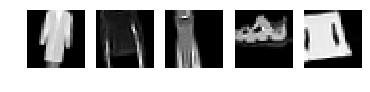

In [119]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train_norm, batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [0]:
checkpt_dg= tf.keras.callbacks.EarlyStopping(monitor='acc',  patience=5, verbose=0, mode='auto', baseline=None, restore_best_weights=True)

In [0]:
#Initialize model, reshape & normalize data
model_a1 = tf.keras.models.Sequential()

#Add Layers
model_a1.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model_a1.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model_a1.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model_a1.add(tf.keras.layers.Dropout(0.25))
model_a1.add(tf.keras.layers.Flatten())
model_a1.add(tf.keras.layers.Dense(128, activation='relu'))
model_a1.add(tf.keras.layers.Dense(10, activation='softmax'))
model_a1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [134]:
hist = model_a1.fit_generator(datagen.flow(x_train_norm, y_train_hot, batch_size=32), 
                    validation_data=datagen.flow(x_test_norm, y_test_hot, batch_size=32),
                    steps_per_epoch=len(x_train) / 32, epochs=10, callbacks=[checkpt_dg])

Epoch 1/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4059 - acc: 0.8510 - val_loss: 0.3944 - val_acc: 0.8515
Epoch 2/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4002 - acc: 0.8527 - val_loss: 0.3903 - val_acc: 0.8569
Epoch 3/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.3930 - acc: 0.8545 - val_loss: 0.3978 - val_acc: 0.8514
Epoch 4/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.3896 - acc: 0.8552 - val_loss: 0.3680 - val_acc: 0.8640
Epoch 5/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.3855 - acc: 0.8572 - val_loss: 0.3753 - val_acc: 0.8672
Epoch 6/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.3840 - acc: 0.8581 - val_loss: 0.3765 - val_acc: 0.8620
Epoch 7/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.3789 - acc: 0.8588 - val_loss: 0.3809 - val_acc: 0.8624
Epoch 8/10
1875/1875 [==========================

###  Report the final train and validation accuracy

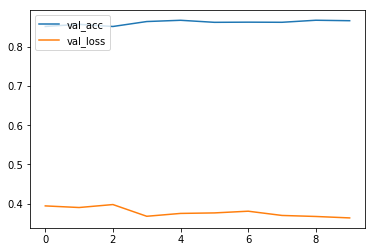

In [136]:
import matplotlib.pyplot as plt

plt.plot(hist.history['val_acc'])
plt.plot(hist.history['val_loss'])
plt.legend(['val_acc', 'val_loss'], loc='upper left')

plt.show()


In [137]:
print("Train accuracy", hist.history["acc"][-1])
print("Test accuracy", hist.history["val_acc"][-1])

Final train accuracy 0.8660833
Final test accuracy 0.8661


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
import keras
from keras.datasets import cifar10
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
import os

### **Load CIFAR10 dataset**

In [0]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [0]:
y_train_h = tf.keras.utils.to_categorical(y_train)
y_test_h = tf.keras.utils.to_categorical(y_test)

In [0]:
x_train_n = x_train/255
x_test_n = x_test/255

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
 datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        zca_epsilon=1e-06,  # epsilon for ZCA whitening
        rotation_range=5,  # randomly rotate images in the range (degrees, 0 to 180)
        # randomly shift images horizontally (fraction of total width)
        width_shift_range=0.1,
        # randomly shift images vertically (fraction of total height)
        height_shift_range=0.1,
        shear_range=0.,  # set range for random shear
        zoom_range=0.,  # set range for random zoom
        channel_shift_range=0.,  # set range for random channel shifts
        # set mode for filling points outside the input boundaries
        fill_mode='nearest',
        cval=0.,  # value used for fill_mode = "constant"
        horizontal_flip=True,  # randomly flip images
        vertical_flip=False,  # randomly flip images
        # set rescaling factor (applied before any other transformation)
        rescale=None,
        # set function that will be applied on each input
        preprocessing_function=None,
        # image data format, either "channels_first" or "channels_last"
        data_format=None,
        # fraction of images reserved for validation (strictly between 0 and 1)
        validation_split=0.0)


### **Prepare/fit the generator.**

In [0]:
datagen.fit(x_train_n)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

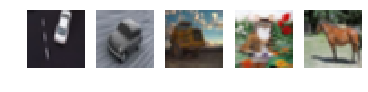

In [154]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train_n, batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()